# Sales Prediction Project
This notebook includes:
- EDA with visualizations
- Multiple ML models
- Model comparison
- Better insights


In [29]:
# -------------------- Imports --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [30]:
# -------------------- Load Data --------------------
df = pd.read_csv("advertising.csv")  # Ensure columns: TV, Radio, Newspaper, Sales
print("First 5 rows:")
print(df.head())

print("\nMissing values check:")
print(df.isnull().sum())

print("\nDataset description:")
print(df.describe())


First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Missing values check:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Dataset description:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


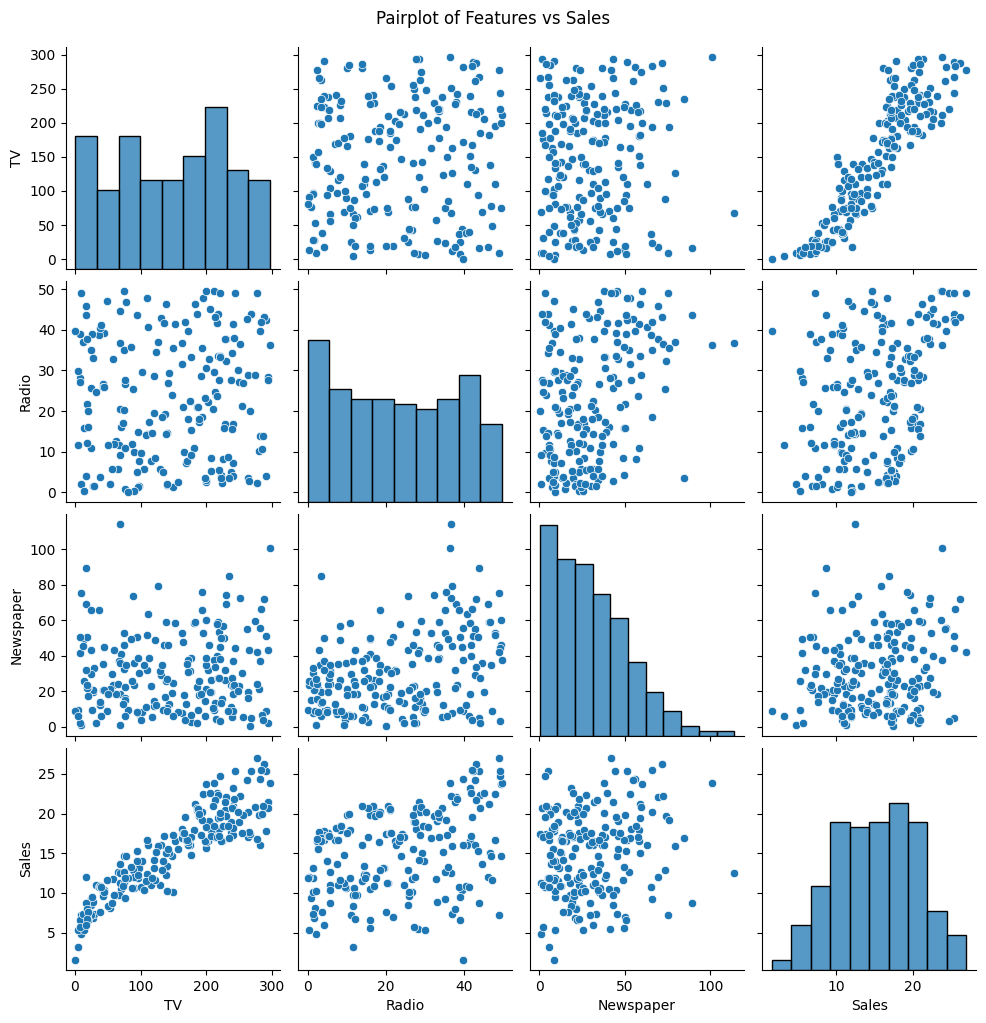

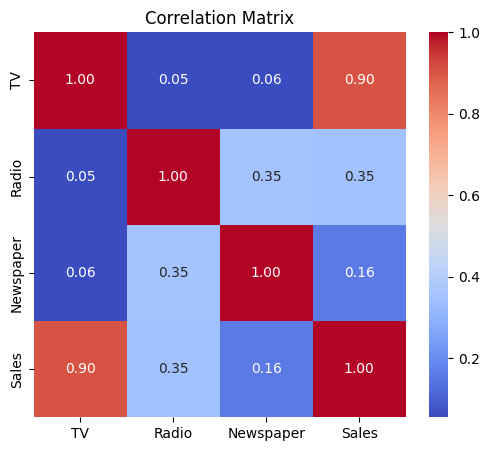

In [31]:
# -------------------- Visualizations --------------------
# Pairplot
sns.pairplot(df)
plt.suptitle("Pairplot of Features vs Sales", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [32]:
# -------------------- Features & Target --------------------
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [33]:
# -------------------- Models --------------------
models = {
    'LinearRegression': LinearRegression(),
    
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ]),
    
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=0.1))
    ]),
    
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('elastic', ElasticNet(alpha=0.1, l1_ratio=0.5))
    ]),
    
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf'))
    ])
}
results = []

for name, model in models.items():
    np.random.seed(42)
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation R2 (optional)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    
    results.append([name, mae, rmse, r2, cv_r2])

results_df = pd.DataFrame(results, columns=['Model','MAE','RMSE','R2','CV_R2'])
print("\nModel Comparison:")
print(results_df)

# Round results for cleaner display
results_df = results_df.round(3)

# Select best model based on R2
best_model_name = results_df.sort_values(by='R2', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

print(f"\nBest Model Selected: {best_model_name}")



Model Comparison:
              Model       MAE      RMSE        R2     CV_R2
0  LinearRegression  1.274826  1.705215  0.905901  0.895372
1             Ridge  1.273447  1.707430  0.905656  0.895429
2             Lasso  1.270139  1.711768  0.905177  0.895448
3        ElasticNet  1.297932  1.746077  0.901337  0.892969
4      DecisionTree  1.200093  1.756611  0.900143  0.899791
5      RandomForest  0.918000  1.198930  0.953483  0.941660
6        ExtraTrees  0.777875  1.100923  0.960777  0.950613
7  GradientBoosting  0.830120  1.120384  0.959378  0.938874
8               SVR  1.555355  2.102626  0.856930  0.831431

Best Model Selected: ExtraTrees


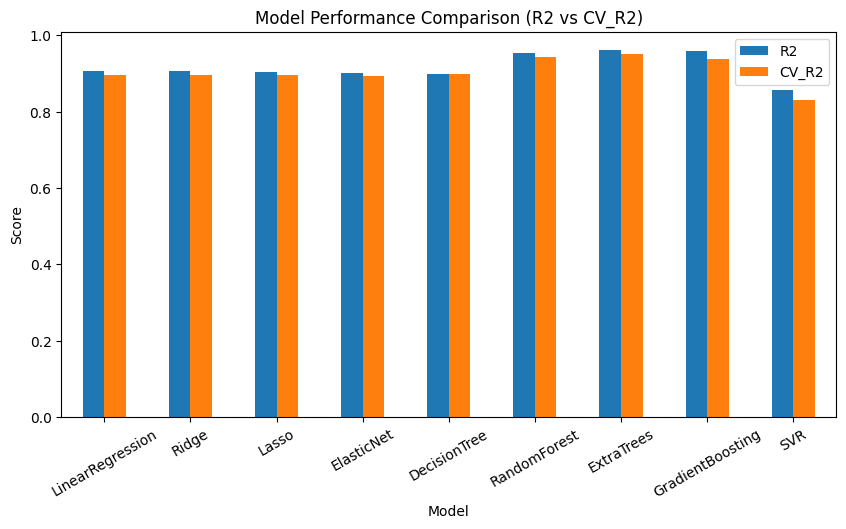

In [34]:
# -------------------- Optimized Bar Plot --------------------
results_df.set_index('Model')[['R2', 'CV_R2']].plot(kind='bar', figsize=(10,5))
plt.title("Model Performance Comparison (R2 vs CV_R2)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()


In [35]:
# -------------------- Feature Importance --------------------
if best_model_name == 'RandomForest':
    importances = best_model.feature_importances_
    
    plt.figure(figsize=(6,4))
    sns.barplot(x=X.columns, y=importances)
    plt.title("Feature Importance (RandomForest)")
    plt.ylabel("Importance")
    plt.show()
    
    # Print interpretation
    for feature, importance in zip(X.columns, importances):
        print(f"{feature}: {round(importance,3)}")
else:
    print("\nFeature importance not available for this model.")


Feature importance not available for this model.


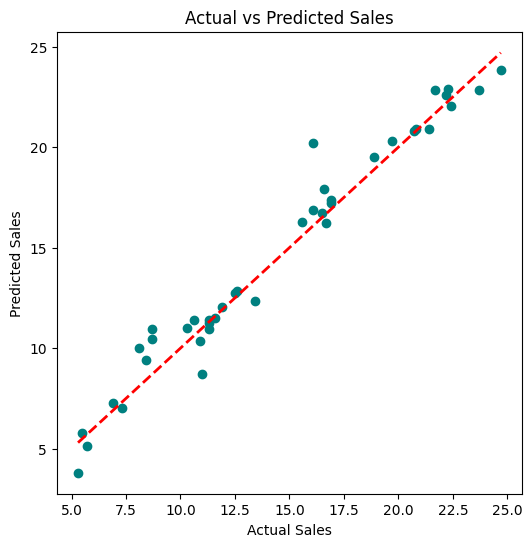

In [36]:
# -------------------- Predictions vs Actual --------------------
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


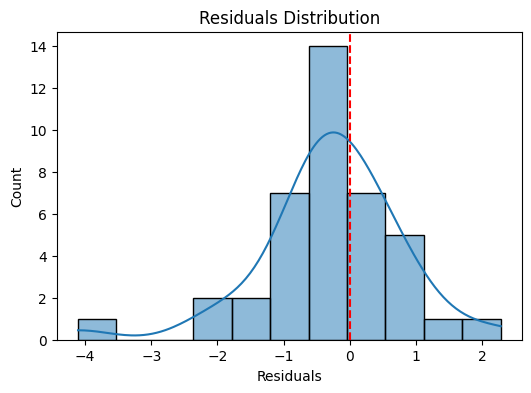

In [37]:
# -------------------- Residual Analysis --------------------
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.show()

In [38]:
# -------------------- Example Prediction --------------------
sample_input = pd.DataFrame({
    'TV': [150],
    'Radio': [30],
    'Newspaper': [20]
})

predicted_sales = best_model.predict(sample_input)

print("\nSample Prediction:")
print(f"Input -> TV:150, Radio:30, Newspaper:20")
print(f"Predicted Sales: {round(predicted_sales[0], 2)}")


Sample Prediction:
Input -> TV:150, Radio:30, Newspaper:20
Predicted Sales: 15.85


In [40]:
import pickle

# Save best model
with open('best_ad_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature columns (important for consistency)
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("\nModel saved successfully!")


Model saved successfully!
